# FEATURE-BASED SET OF EXPERIMENTS: THREE LABELS (LVOT-RVOT-Commisure)
Classify between RVOT-(RCC/LCC/Commisure)-(LVOT Summit/Subvalvular)

**Hypothesis**: This set of experiments are done under the hypothesis that if feature-based approaches were the best for binary classification, they will also be for three-class classification tasks.

**Content of the file**: This file includes all the experiments done for three-class classification of the site-of-origin in idiopathic ventricular arrythmias. First a dataset assessment to see which combination of all the available ones gives a better performance on the Teknon dataset. Followed by the choice of a best model and its refinement. Then a comparison to the performance on training with the Teknon dataset on its own including demographic data.
The test split follows a hold-out strategy with 20% of the teknon samples. All the cross-validation evaluations are done only on Teknon training samples.

### Utilities

In [66]:
# If you are executing on google colab, mount it
'''from google.colab import drive
drive.mount('/content/drive')'''

"from google.colab import drive\ndrive.mount('/content/drive')"

In [67]:
import os, pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import copy
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch.nn.functional as F
from torch.utils.data import Dataset
from scipy import signal
from scipy.io import loadmat
from scipy.stats import kurtosis, skew
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score,
                              confusion_matrix, ConfusionMatrixDisplay)
import xgboost as xgb
import shap

print("Imports OK")

Imports OK


In [68]:
SAMPLE_SIZE  = 277
RANDOM_STATE = 42
N_FOLDS      = 5
LEADS        = ['I','II','III','AVR','AVL','AVF','V1','V2','V3','V4','V5','V6']
LEADS_MAT    = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
BAR_WIDTH    = 0.2
MODEL_NAMES  = ['XGBoost', 'RandomForest', 'SVM_RBF', 'LogReg']
COLORS       = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# Mapping of 3 classes (0: LVOT, 1: CC, 2: RVOT)
MAP_3CLASSES = {
    'RVOT Septum': 2, 'RVOTSEPTUM': 2, 
    'RFW': 2, 'RVOTFREEWALL': 2,
    'LCC': 1, 'RCC': 1, 'COMMISSURE': 1, '\\COMMISSURE': 1,
    'LVOT Subvalvular': 0, 'LVOTSUBVALVULAR': 0,
    'LVOT Summit': 0, 'LVOTSUMMIT': 0
}

CLASS_LABELS = ['LVOT', 'CC', 'RVOT']

# Paths
base_path = ""
#base_path = "/content/drive/Shareddrives/CompBioMed/seminars" #If using Google Colab with Drive

PATH_ALIGNED     = os.path.join(base_path, 'outputs', 'aligned_qrs.pkl')
PATH_IDENTIFIERS = os.path.join(base_path, 'outputs', 'qrs_identifiers.pkl')
PATH_DATA        = os.path.join(base_path, 'data',    'multiclass_full_dataset.parquet') 
PATH_CARTO       = os.path.join(base_path, 'data',    'QRS_CARTO2.mat')
PATH_CHINA       = os.path.join(base_path, 'data',    'QRS_Database2.mat')
PATH_SIMS        = os.path.join(base_path, 'data',    'QRS_Sims2.mat')

In [ ]:
def _build_binary_target(dSim, data_key):
    mapping  = {'LV': 0, 'RV': 1}
    key_name = ('LeftRight' if 'LeftRight' in dSim[data_key].dtype.names
                else 'LeftRigth')
    raw_labels = dSim[data_key][key_name]
    y = np.zeros(len(raw_labels[0]), dtype=np.int64)
    for i, label in enumerate(raw_labels[0]):
        y[i] = mapping[label[0]]
    return y


def _handle_sublocation(dSim: dict,
                        data_key: str,
                        path: str,
                        X: np.ndarray,
                        y: np.ndarray) -> (np.ndarray, np.ndarray, np.ndarray):
    """
    Handle sublocation classification and remove invalid samples.
    """
    mapping_3cls = {
        'LCC': 1,
        'RCC': 1,
        'COMMISSURE': 1,
        'LVOT Subvalvular': 0,
        'LVOT Summit': 0,
        'LV': 0,
        'RV': 2,
        'RVOT Septum': 2,
        'RFW': 2,
        'RVOTOther': 2
    }

    #Dataset-specific exclusions
    if path == 'data/QRS_CARTO2.mat':
        invalid_labels = ['RV', []]
    elif path == 'data/QRS_Database2.mat':
        invalid_labels = ['-']
    else:
        invalid_labels = []

    raw_labels = dSim[data_key]["Sublocation"]

    y_sub = []
    valid_indices = []
    unique_labels = []

    for i, label in enumerate(raw_labels[0]):

        try:
            if label[0] in invalid_labels:
                continue

            else:
                if label[0] == 'LCCRCC' or label[0] == 'LCC-RCC':
                    label = 'COMMISSURE'

                elif label[0] == 'Posteroseptal' or label[0] == 'Anteroseptal':
                    label = 'RVOT Septum'

                elif label[0] == "AMC":
                    label = 'LVOT Subvalvular'

                elif label[0] == "Summit":
                    label = 'LVOT Summit'

                else:
                    label = label[0]

                if label in mapping_3cls:
                    y_sub.append(mapping_3cls[label])
                    valid_indices.append(i)
                    if label not in unique_labels:
                        unique_labels.append(label)
                else:
                    print(f"Warning: unknown sublocation '{label}' at index {i}")

        except:
            print(f"Warning: invalid label format at index {i}: {label}")
            continue


    print(f"Unique sublocation labels found: {unique_labels}")
    #Filter dataset
    X = X[valid_indices]
    y = y[valid_indices]
    y_sub = np.array(y_sub)

    return X, y, y_sub


def _load_mat_dataset(path, sample_size, data_key, lead_names, sublocation):
    dSim      = loadmat(path)
    n_patients = dSim[data_key][lead_names[0]].shape[1]
    X = np.zeros((n_patients, len(lead_names), sample_size))

    for iLead, lead in enumerate(lead_names):
        lead_data = dSim[data_key][lead]
        for i in range(n_patients):
            sig = np.asarray(lead_data[0, i]).squeeze()
            if sig.ndim != 1:
                continue
            resampled = signal.resample(sig, sample_size)
            if np.max(np.abs(resampled)) > 0:
                resampled = resampled / np.max(np.abs(resampled))
            X[i, iLead, :] = resampled

    y = _build_binary_target(dSim, data_key)
    y_sub = None
    if sublocation:
        X, y, y_sub = _handle_sublocation(dSim, data_key, path, X, y)
    return X, y, y_sub


def load_dataset(path, sample_size, data_key,
                 lead_names=None, sublocation=False, shuffle=False, random_state=None):
    if lead_names is None:
        lead_names = LEADS_MAT
    print(f'\n--- Loading: {path} ---')
    X, y, y_sub = _load_mat_dataset(path, sample_size, data_key, lead_names, sublocation)
    if shuffle:
        rng = np.random.default_rng(random_state)
        idx = rng.permutation(len(X))
        X, y = X[idx], y[idx]
        if y_sub is not None: 
            y_sub = y_sub[idx]
    print(f'  Shape: {X.shape}  |  LV={(y_sub==0).sum()}  CC={(y_sub==1).sum()}  RVOT={(y_sub==2).sum()}')

    if sublocation:
        return X, y, y_sub
    return X, y

Feature extraction functions

In [70]:
def compute_transition(pacient_feats):
    PRECORDIALS = ["V1", "V2", "V3", "V4", "V5", "V6"]
    TRANSITION_MAPPING = {"V1": 1, "V2": 2, "V3": 3, "V4": 4, "V5": 5, "V6": 6}

    ratios = []
    for lead in PRECORDIALS:
        r_amp = pacient_feats[f'{lead}_R_amp']
        s_amp = pacient_feats[f'{lead}_S_amp']
        R = r_amp
        S = abs(s_amp)
        ratio = np.inf if S == 0 else R / S
        ratios.append(ratio)

    ratios = np.array(ratios)
    idx = np.where(ratios >= 1)[0]
    string_trans = PRECORDIALS[idx[0]] if len(idx) > 0 else "V6"
    return TRANSITION_MAPPING[string_trans]



def extract_features_from_array(X_data, y, source_name, calculate_transition=False, teknon_id_slice=None):
    """
    Extract 72 features per pacient directly from QRS NumPy array
    
    X_data: np.ndarray with shape (n_pacients, 12, 277)
    y: array or list with the labels (targets)
    """
    records = []
    
    for idx in range(len(X_data)):
        ecg = X_data[idx] 
        feats = {}
        
        for i_lead, lead in enumerate(LEADS):
            sig = ecg[i_lead]
            
            r   = np.max(sig)
            s   = np.min(sig)
            
            feats[f'{lead}_R_amp']    = r
            feats[f'{lead}_S_amp']    = s
            feats[f'{lead}_RS_ratio'] = r / (abs(s) + 1e-6)
            feats[f'{lead}_RMS']      = np.sqrt(np.mean(sig**2))
            feats[f'{lead}_Kurtosis'] = kurtosis(sig)
            feats[f'{lead}_Skewness'] = skew(sig)
            
        # Flag logic to determine PVC transition only on .mat datasets
        if calculate_transition:
            feats['PVC_transition'] = compute_transition(feats)
        else:
            if teknon_id_slice is not None and idx < len(teknon_id_slice):
                feats['PVC_transition'] = teknon_id_slice[idx]
            else:
                feats['PVC_transition'] = None

        records.append(feats)
        
    # Create DataFrame and add target and source columns
    df = pd.DataFrame(records)
    df['target']  = y
    df['_source'] = source_name
    
    # Substracting 2 columns for 'target' and '_source'
    print(f'  {source_name:<10}  n={len(df):4d}  features={len(df.columns)-2}')
    
    return df

Running Experiments

In [71]:
def run_ml_experiment(df_tek_feats, df_extra_feats=None, exp_name='exp'):
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    models_def = {
        'XGBoost':      xgb.XGBClassifier(
                            n_estimators=200, max_depth=8,
                            random_state=RANDOM_STATE, eval_metric='mlogloss', objective='multi:softprob', verbosity=0),
        'RandomForest': RandomForestClassifier(
                            n_estimators=200, max_depth=8,
                            random_state=RANDOM_STATE, n_jobs=-1),
        'SVM_RBF':      Pipeline([('imp', SimpleImputer(strategy='median')),
                                  ('sc',  StandardScaler()),
                                  ('clf', SVC(probability=True, random_state=RANDOM_STATE))]),
        'LogReg':       Pipeline([('imp', SimpleImputer(strategy='median')),
                                  ('sc',  StandardScaler()),
                                  ('clf', LogisticRegression(max_iter=1500, multi_class='multinomial',
                                                             random_state=RANDOM_STATE))]),
    }

    X_tek = df_tek_feats[FEATURE_COLS].values
    y_tek = df_tek_feats['target'].values.astype(np.int64)

    if df_extra_feats is not None and len(df_extra_feats) > 0:
        X_extra = df_extra_feats[FEATURE_COLS].values
        y_extra = df_extra_feats['target'].values.astype(np.int64)
    else:
        X_extra, y_extra = None, None

    fold_scores = {name: [] for name in models_def}

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tek, y_tek), 1):
        X_tr_fold = X_tek[tr_idx]
        y_tr_fold = y_tek[tr_idx]
        X_va_fold = X_tek[val_idx]
        y_va_fold = y_tek[val_idx]

        if X_extra is not None:
            X_tr_fold = np.concatenate([X_tr_fold, X_extra], axis=0)
            y_tr_fold = np.concatenate([y_tr_fold, y_extra], axis=0)

        for name, clf in models_def.items():
            clf_clone = copy.deepcopy(clf)
            clf_clone.fit(X_tr_fold, y_tr_fold)
            preds = clf_clone.predict(X_va_fold)
            fold_scores[name].append(f1_score(y_va_fold, preds, average='macro', zero_division=0))

    results = {name: np.mean(scores) for name, scores in fold_scores.items()}
    print(f'  {exp_name:<35}', end='  ')
    for name, score in results.items():
        print(f'{name}={score:.4f}', end='  ')
    print()
    return results

Plotting functions

In [80]:
def plot_results(df, title, ylabel):
    fig, ax = plt.subplots(figsize=(14, 5))
    x = np.arange(len(df))
    
    for i, (m, c) in enumerate(zip(MODEL_NAMES, COLORS)):
        # Calculate the mean and std
        model_mean = df[m].mean()
        model_std = df[m].std()

        #Include the statistics to the label
        label = f'{m} (mean={model_mean:.3f}, std={model_std:.3f})'


        ax.bar(x + i * BAR_WIDTH, df[m], BAR_WIDTH, label=label, color=c, edgecolor='black', linewidth=0.5)
        
    ax.set_xticks(x + BAR_WIDTH * 1.5)
    ax.set_xticklabels(df.index, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.axhline(0.333, color='red', linestyle='--', linewidth=1, label='Chance')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

### Dataset Assessment

In [77]:
print("Loading Teknon signals and identifiers...")

with open(PATH_ALIGNED, 'rb') as f:
    aligned_ecgs = pickle.load(f)

with open(PATH_IDENTIFIERS, 'rb') as f:
    df_id = pickle.load(f)

X_teknon_all = np.array(aligned_ecgs, dtype=np.float32)

if X_teknon_all.shape[1] == 277:
    X_teknon_all = np.transpose(X_teknon_all, (0, 2, 1))

print("Loading clinical data...")

df_clinics = pd.read_parquet(PATH_DATA)

df_clinics = df_clinics.drop(columns=LEADS, errors='ignore')

df_clinics['Final_Label'] = df_clinics['Final_Label'].map(MAP_3CLASSES)
df_clinics = df_clinics.dropna(subset=['Final_Label'])

print(df_clinics.columns)

X_teknon = X_teknon_all[df_id.index.get_indexer(df_clinics.index)]
y_teknon = df_clinics['Final_Label'].values

print(f'Teknon data shape: {X_teknon.shape}  |  LV={(y_teknon==0).sum()}  CC={(y_teknon==1).sum()}  RVOT={(y_teknon==2).sum()}')

Loading Teknon signals and identifiers...
Loading clinical data...
Index(['patient_id', 'Sex', 'HTA', 'Age', 'PVC_transition', 'Height', 'Weight',
       'BMI', 'DM', 'DLP', 'Smoker', 'COPD', 'Sleep_apnea', 'CLINICAL_SCORE',
       'missing_rate', 'Final_Label'],
      dtype='object')
Teknon data shape: (179, 12, 277)  |  LV=43  CC=33  RVOT=103


In [78]:
X_Sims, _, y_Sims   = load_dataset(PATH_SIMS,  SAMPLE_SIZE, 'QRS_Sims', sublocation=True,random_state=RANDOM_STATE)
X_China, _, y_China = load_dataset(PATH_CHINA, SAMPLE_SIZE, 'QRS', sublocation=True,random_state=RANDOM_STATE)
X_Carto, _, y_Carto = load_dataset(PATH_CARTO, SAMPLE_SIZE, 'QRS_CARTO', sublocation=True,random_state=RANDOM_STATE)


split_idx = int(0.8 * len(y_teknon))
X_tek_cv,   y_tek_cv   = X_teknon[:split_idx], y_teknon[:split_idx]
X_tek_test, y_tek_test = X_teknon[split_idx:], y_teknon[split_idx:]


print('\nExtracting features...')
df_tek      = extract_features_from_array(X_tek_cv,   y_tek_cv,   'teknon_cv',   calculate_transition=True) # It should take the one from the doctors 
df_tek_test = extract_features_from_array(X_tek_test, y_tek_test, 'teknon_test', calculate_transition=True)
df_sims     = extract_features_from_array(X_Sims,   y_Sims,   'sims',  calculate_transition=True)
df_china    = extract_features_from_array(X_China,  y_China,  'china', calculate_transition=True)
df_carto    = extract_features_from_array(X_Carto,  y_Carto,  'carto', calculate_transition=True)



--- Loading: data\QRS_Sims2.mat ---
Unique sublocation labels found: ['LCC', 'COMMISSURE', 'RCC', 'LVOT Subvalvular', 'LVOT Summit', 'RVOT Septum', 'RFW']
  Shape: (2496, 12, 277)  |  LV=416  CC=1040  RVOT=1040

--- Loading: data\QRS_Database2.mat ---
Unique sublocation labels found: ['RFW', 'RVOT Septum', 'RCC', 'LCC', 'LVOT Summit', 'LVOT Subvalvular', 'RVOTOther', 'COMMISSURE']
  Shape: (293, 12, 277)  |  LV=23  CC=53  RVOT=217

--- Loading: data\QRS_CARTO2.mat ---
Unique sublocation labels found: ['RCC', 'LCC', 'RV', 'COMMISSURE']
  Shape: (38, 12, 277)  |  LV=0  CC=21  RVOT=17

Extracting features...
  teknon_cv   n= 143  features=73
  teknon_test  n=  36  features=73
  sims        n=2496  features=73
  china       n= 293  features=73
  carto       n=  38  features=73



ML Experiments — Multiclass (3 Classes) — CV on Teknon
  exp0: Only Teknon                    XGBoost=0.2946  RandomForest=0.3196  SVM_RBF=0.2504  LogReg=0.4388  
  exp1: Sims + Teknon                  XGBoost=0.3107  RandomForest=0.3059  SVM_RBF=0.2507  LogReg=0.3255  
  exp2: China + Teknon                 XGBoost=0.2884  RandomForest=0.2880  SVM_RBF=0.2485  LogReg=0.3436  
  exp3: CARTO + Teknon                 XGBoost=0.2908  RandomForest=0.3035  SVM_RBF=0.2504  LogReg=0.3882  
  exp4: China + Sims + Teknon          XGBoost=0.3202  RandomForest=0.2738  SVM_RBF=0.2507  LogReg=0.3078  
  exp5: CARTO + Sims + Teknon          XGBoost=0.3060  RandomForest=0.2910  SVM_RBF=0.2507  LogReg=0.2949  
  exp6: CARTO + China + Teknon         XGBoost=0.2496  RandomForest=0.3091  SVM_RBF=0.2609  LogReg=0.3604  
  exp7: Tots                           XGBoost=0.2421  RandomForest=0.3055  SVM_RBF=0.2507  LogReg=0.2728  


,XGBoost,RandomForest,SVM_RBF,LogReg
Experiment,,,,
exp0: Only Teknon,0.2946,0.3196,0.2504,0.4388
exp1: Sims + Teknon,0.3107,0.3059,0.2507,0.3255
exp2: China + Teknon,0.2884,0.2880,0.2485,0.3436
exp3: CARTO + Teknon,0.2908,0.3035,0.2504,0.3882
exp4: China + Sims + Teknon,0.3202,0.2738,0.2507,0.3078
exp5: CARTO + Sims + Teknon,0.3060,0.2910,0.2507,0.2949
exp6: CARTO + China + Teknon,0.2496,0.3091,0.2609,0.3604
exp7: Tots,0.2421,0.3055,0.2507,0.2728



HOLD-OUT TEST EVALUATION (MULTICLASS)
  Training exp0: Only Teknon                        -> 
  Training exp1: Sims + Teknon                      -> 
  Training exp2: China + Teknon                     -> 
  Training exp3: CARTO + Teknon                     -> 
  Training exp4: China + Sims + Teknon              -> 
  Training exp5: CARTO + Sims + Teknon              -> 
  Training exp6: CARTO + China + Teknon             -> 
  Training exp7: Tots                               -> 


,XGBoost,RandomForest,SVM_RBF,LogReg
Experiment,,,,
exp0: Only Teknon,0.3017,0.2092,0.2138,0.3825
exp1: Sims + Teknon,0.3651,0.2138,0.2138,0.3744
exp2: China + Teknon,0.3935,0.2828,0.2846,0.3502
exp3: CARTO + Teknon,0.3203,0.2179,0.2138,0.3303
exp4: China + Sims + Teknon,0.2690,0.2051,0.2138,0.3921
exp5: CARTO + Sims + Teknon,0.3036,0.2138,0.2138,0.3725
exp6: CARTO + China + Teknon,0.2735,0.2179,0.2846,0.3399
exp7: Tots,0.3424,0.2138,0.2138,0.4086


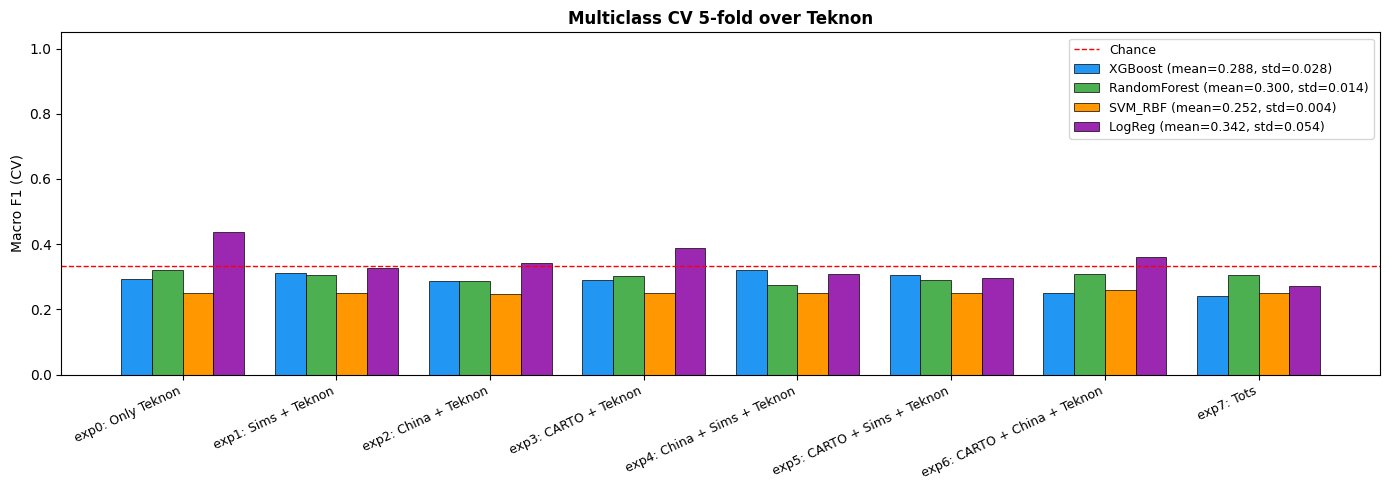

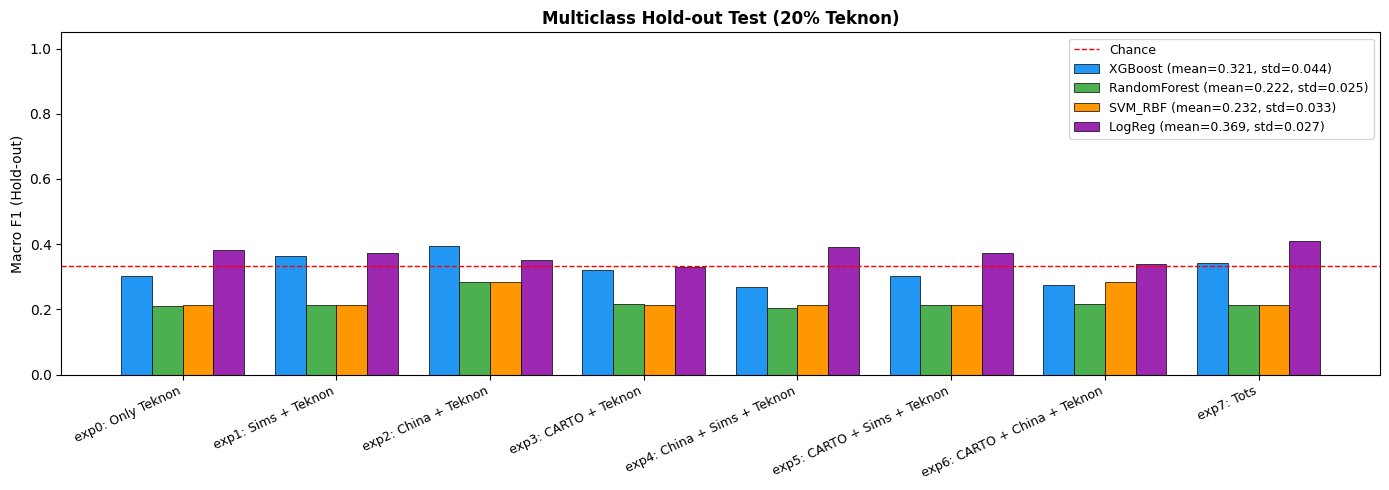

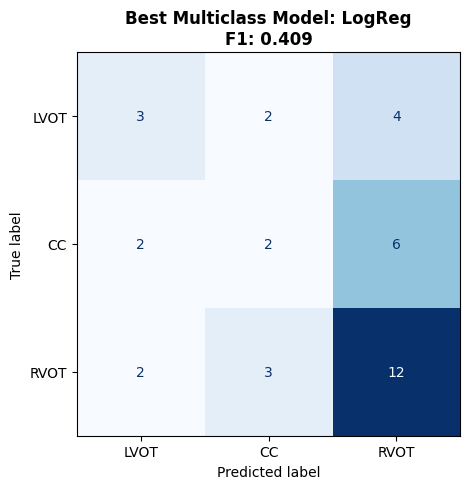

In [81]:
FEATURE_COLS = [c for c in df_tek.columns if c not in ['target', '_source']]

models_base = {
    'XGBoost': xgb.XGBClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE, eval_metric='mlogloss', objective='multi:softprob', verbosity=0),
    'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1),
    'SVM_RBF': Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler()), ('clf', SVC(probability=True, random_state=RANDOM_STATE))]),
    'LogReg': Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1500, multi_class='multinomial', random_state=RANDOM_STATE))]),
}

print('\nML Experiments — Multiclass (3 Classes) — CV on Teknon')
resum = []
resum.append({'Experiment': 'exp0: Only Teknon', **run_ml_experiment(df_tek, exp_name='exp0: Only Teknon')})
resum.append({'Experiment': 'exp1: Sims + Teknon', **run_ml_experiment(df_tek, df_sims, exp_name='exp1: Sims + Teknon')})
resum.append({'Experiment': 'exp2: China + Teknon', **run_ml_experiment(df_tek, df_china, exp_name='exp2: China + Teknon')})
resum.append({'Experiment': 'exp3: CARTO + Teknon', **run_ml_experiment(df_tek, df_carto, exp_name='exp3: CARTO + Teknon')})

df_e4 = pd.concat([df_china, df_sims], ignore_index=True)
resum.append({'Experiment': 'exp4: China + Sims + Teknon', **run_ml_experiment(df_tek, df_e4, exp_name='exp4: China + Sims + Teknon')})
df_e5 = pd.concat([df_carto, df_sims], ignore_index=True)
resum.append({'Experiment': 'exp5: CARTO + Sims + Teknon', **run_ml_experiment(df_tek, df_e5, exp_name='exp5: CARTO + Sims + Teknon')})
df_e6 = pd.concat([df_carto, df_china], ignore_index=True)
resum.append({'Experiment': 'exp6: CARTO + China + Teknon', **run_ml_experiment(df_tek, df_e6, exp_name='exp6: CARTO + China + Teknon')})
df_e7 = pd.concat([df_carto, df_china, df_sims], ignore_index=True)
resum.append({'Experiment': 'exp7: Tots', **run_ml_experiment(df_tek, df_e7, exp_name='exp7: Tots')})

df_resum = pd.DataFrame(resum).set_index('Experiment')
display(df_resum.round(4))

# HOLD-OUT TEST EVALUATION MULTICLASE
print('\nHOLD-OUT TEST EVALUATION (MULTICLASS)')
X_ho = df_tek_test[FEATURE_COLS].values
y_ho = df_tek_test['target'].values.astype(np.int64)

experiments_extra = {
    'exp0: Only Teknon': None, 'exp1: Sims + Teknon': df_sims, 'exp2: China + Teknon': df_china,
    'exp3: CARTO + Teknon': df_carto, 'exp4: China + Sims + Teknon': df_e4,
    'exp5: CARTO + Sims + Teknon': df_e5, 'exp6: CARTO + China + Teknon': df_e6, 'exp7: Tots': df_e7
}

holdout_results = []
best_score = -1.0; best_cm_data = None; best_model_info = {}

for exp_name, df_extra in experiments_extra.items():
    X_train_full = df_tek[FEATURE_COLS].values
    y_train_full = df_tek['target'].values.astype(np.int64)
    if df_extra is not None:
        X_train_full = np.concatenate([X_train_full, df_extra[FEATURE_COLS].values], axis=0)
        y_train_full = np.concatenate([y_train_full, df_extra['target'].values.astype(np.int64)], axis=0)

    row = {'Experiment': exp_name}
    print(f"  Training {exp_name:<40}", end=' -> ')
    for name, clf in models_base.items():
        clf_clone = copy.deepcopy(clf)
        clf_clone.fit(X_train_full, y_train_full)
        preds = clf_clone.predict(X_ho)
        score = f1_score(y_ho, preds, average='macro', zero_division=0)
        row[name] = score
        if score > best_score:
            best_score = score
            best_cm_data = confusion_matrix(y_ho, preds)
            best_model_info = {'model': name, 'experiment': exp_name, 'score': score}
    print()
    holdout_results.append(row)

df_holdout = pd.DataFrame(holdout_results).set_index('Experiment')
display(df_holdout.round(4))

plot_results(df_resum, 'Multiclass CV 5-fold over Teknon', 'Macro F1 (CV)')
plot_results(df_holdout, 'Multiclass Hold-out Test (20% Teknon)', 'Macro F1 (Hold-out)')

if best_cm_data is not None:
    fig, ax = plt.subplots(figsize=(5, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=best_cm_data, display_labels=CLASS_LABELS)
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(f"Best Multiclass Model: {best_model_info['model']}\nF1: {best_model_info['score']:.3f}", fontweight='bold')
    plt.tight_layout(); plt.show()


--- Tuning Logistic Regression for Multiclass (3 Classes) ---
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Parameters found: {'clf__solver': 'saga', 'clf__penalty': 'l1', 'clf__C': 0.23357214690901212}

Final Multiclass Test Macro F1 (Optimized LogReg): 0.4069


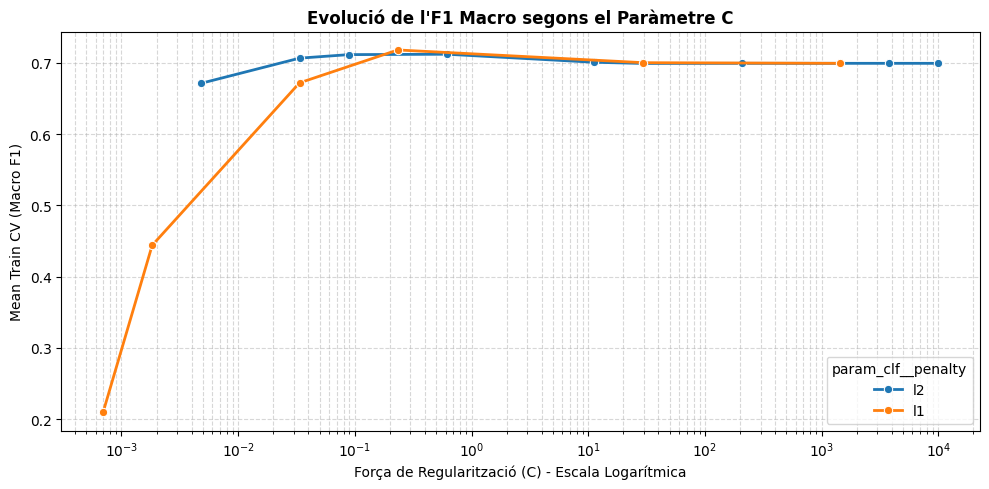

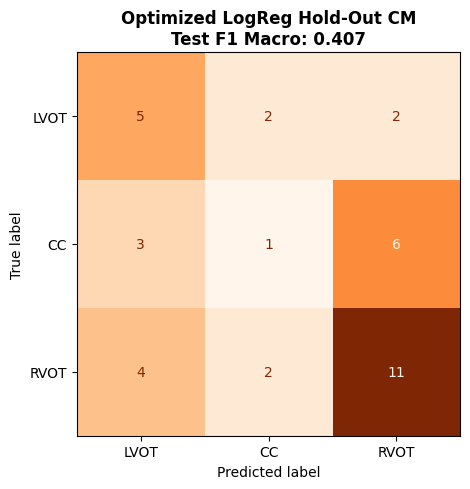

In [84]:
print("\n--- Tuning Logistic Regression for Multiclass (3 Classes) ---")

# Combine all the datasets to refine the Logistic Regression model
X_train_augmented = np.concatenate([
    df_tek[FEATURE_COLS].values, 
    df_carto[FEATURE_COLS].values,
    df_china[FEATURE_COLS].values, 
    df_sims[FEATURE_COLS].values
], axis=0)

y_train_augmented = np.concatenate([
    df_tek['target'].values, 
    df_carto['target'].values,
    df_china['target'].values, 
    df_sims['target'].values
], axis=0).astype(np.int64)

# LogReg pipeline requires imputing and scalinfg
pipe_logreg = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc',  StandardScaler()),
    ('clf', LogisticRegression(multi_class='multinomial', random_state=RANDOM_STATE, max_iter=3000))
])

# Hyperparameter space for Logistic Regression
param_dist_lr = {
    "clf__C": np.logspace(-4, 4, 20),                 # Forces regularization
    "clf__penalty": ["l1", "l2"],                     # Types of regularization
    "clf__solver": ["saga"]                           # 'saga' is the only solver that supports both 'l1' and 'l2' 
}

# Randomized Search optimized by F1 Macro score with 5-fold CV
search_lr = RandomizedSearchCV(
    estimator=pipe_logreg, 
    param_distributions=param_dist_lr, 
    n_iter=15, 
    scoring="f1_macro", 
    cv=5, 
    verbose=1, 
    random_state=RANDOM_STATE, 
    n_jobs=-1
)
search_lr.fit(X_train_augmented, y_train_augmented)

best_logreg = search_lr.best_estimator_
print(f"Best Parameters found: {search_lr.best_params_}")

# Final evaluation on the Hold-Out Test of Teknon (X_ho and y_ho must be defined previously)
y_pred_ho = best_logreg.predict(X_ho)
test_f1 = f1_score(y_ho, y_pred_ho, average="macro", zero_division=0)
print(f"\nFinal Multiclass Test Macro F1 (Optimized LogReg): {test_f1:.4f}")

df_cv_results = pd.DataFrame(search_lr.cv_results_)

# Plot 1: Performance according to Regularization Strength (C) and Penalty
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df_cv_results, 
    x='param_clf__C', 
    y='mean_test_score', 
    hue='param_clf__penalty', 
    marker='o',
    linewidth=2,
    palette=['#1f77b4', '#ff7f0e']
)
plt.xscale('log')
plt.title('Evolució de l\'F1 Macro segons el Paràmetre C', fontweight='bold', fontsize=12)
plt.xlabel('Força de Regularització (C) - Escala Logarítmica')
plt.ylabel('Mean Train CV (Macro F1)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Plot 2: Confusion Matrix of the best LogReg model found
cm_opt_logreg = confusion_matrix(y_ho, y_pred_ho)
fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_opt_logreg, display_labels=CLASS_LABELS)
disp.plot(ax=ax, cmap='Oranges', values_format='d', colorbar=False)
ax.set_title(f"Optimized LogReg Hold-Out CM\nTest F1 Macro: {test_f1:.3f}", fontweight='bold')
plt.tight_layout()
plt.show()


Computing SHAP values for Multiclass Linear model...
SHAP Values Shape: (2970, 73, 3) (samples, features, classes)


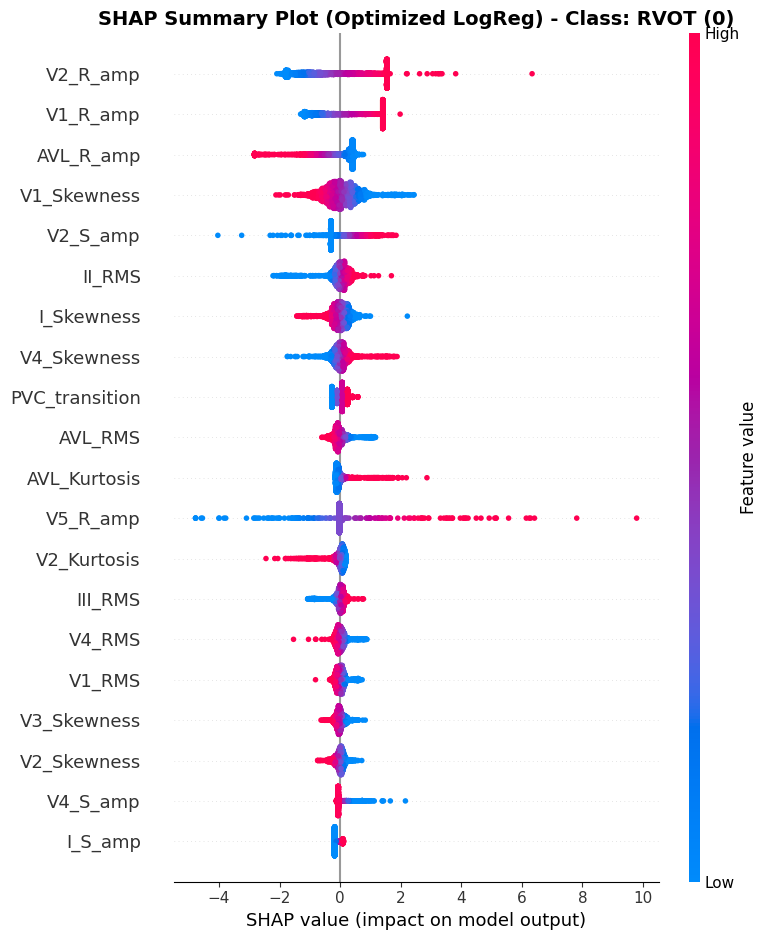

In [ ]:
print("\nComputing SHAP values for Multiclass Linear model...")

# Transform the training data with the same preprocessor used in the pipeline (imputation + scaling)
preprocessor = Pipeline(best_logreg.steps[:-1])
X_train_augmented_transformed = preprocessor.transform(X_train_augmented)

# Choose the best classfier from the pipeline
clf_model = best_logreg.steps[-1][1]

# For linear models explainer is used
explainer = shap.Explainer(clf_model, X_train_augmented_transformed)
shap_values = explainer(X_train_augmented_transformed)


print(f"SHAP Values Shape: {shap_values.shape} (samples, features, classes)")

# Isolate SHAP values for class 0 (RVOT) for the summary plot
if hasattr(shap_values, 'values') and len(shap_values.shape) == 3:
    shap_values_class0 = shap_values[:, :, 0]
else:
    shap_values_class0 = shap_values[0] #To handle matrices

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_class0, 
    X_train_augmented_transformed, 
    feature_names=FEATURE_COLS, 
    max_display=20, 
    show=False
)
plt.title("SHAP Summary Plot (Optimized LogReg) - Class: RVOT (0)", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()